## Introducción

En este proyecto práctico se entrena un modelo de detección de objetos utilizando YOLOv8, con el dataset COCO y una cantidad reducida de imágenes (val2017, 300 imágenes). Se realizan transformaciones con Albumentations, conversión de anotaciones de formato COCO a YOLO y visualización de ejemplos aumentados, siguiendo la metodología propuesta en las clases 3 y 4 del módulo.

### 1. Preparación del Entorno: Instalación de librerías.

In [5]:
# Instalar la biblioteca YOLOv8
!pip install ultralytics --quiet

# Instalar OpenCV para trabajar con imágenes
!pip install opencv-python --quiet

# Instalar albumentations para aumentar datos
!pip install albumentations --quiet

# Instalar matplotlib para mostrar imágenes
!pip install matplotlib --quiet

# Instalar PyYAML (requisito interno de YOLO)
!pip install pyyaml --quiet

# Instalar scikit-learn
!pip install scikit-learn --quiet


In [9]:
# Importar bibliotecas necesarias
import os
import urllib.request
import zipfile
import shutil 
from sklearn.model_selection import train_test_split
import json
from tqdm import tqdm
import cv2
import albumentations as A
from albumentations.pytorch import ToTensorV2
import matplotlib.pyplot as plt
import random
import shutil 
from sklearn.model_selection import train_test_split
from ultralytics import YOLO

### 2. Recolección de Datos: Descarga y descompresión del dataset COCO. 

In [ ]:
# Crear carpeta para el dataset si no existe
os.makedirs("data", exist_ok=True)

# Definir URLs de descarga
url_images = "http://images.cocodataset.org/zips/val2017.zip"
url_annotations = "http://images.cocodataset.org/annotations/annotations_trainval2017.zip"

# Definir rutas de destino
ruta_img_zip = "data/val2017.zip"
ruta_ann_zip = "data/annotations_trainval2017.zip"

# Descargar imágenes del conjunto de validación
print("Descargando imágenes...")
urllib.request.urlretrieve(url_images, ruta_img_zip)

# Descargar anotaciones
print("Descargando anotaciones...")
urllib.request.urlretrieve(url_annotations, ruta_ann_zip)

# Extraer archivos ZIP
print("Extrayendo imágenes...")
with zipfile.ZipFile(ruta_img_zip, 'r') as zip_ref:
    zip_ref.extractall("data")

print("Extrayendo anotaciones...")
with zipfile.ZipFile(ruta_ann_zip, 'r') as zip_ref:
    zip_ref.extractall("data")


Descargando imágenes...
Descargando anotaciones...
Extrayendo imágenes...
Extrayendo anotaciones...


In [ ]:
# Crear carpetas para dataset formateado
base = "data/dataset_yolo"
os.makedirs(f"{base}/images/train", exist_ok=True)
os.makedirs(f"{base}/images/val", exist_ok=True)
os.makedirs(f"{base}/labels/train", exist_ok=True)
os.makedirs(f"{base}/labels/val", exist_ok=True)

# Obtener lista de imágenes aumentadas
imagenes = os.listdir("data/val2017_aug")
imagenes = [img for img in imagenes if img.endswith(".jpg")]

# Separar 80% treino, 20% validação
train_imgs, val_imgs = train_test_split(imagenes, test_size=0.2, random_state=42)

# Copiar archivos
for img in train_imgs:
    shutil.copy(f"data/val2017_aug/{img}", f"{base}/images/train/{img}")
    shutil.copy(f"data/labels_val2017_aug/{img.replace('.jpg', '.txt')}", f"{base}/labels/train/{img.replace('.jpg', '.txt')}")

for img in val_imgs:
    shutil.copy(f"data/val2017_aug/{img}", f"{base}/images/val/{img}")
    shutil.copy(f"data/labels_val2017_aug/{img.replace('.jpg', '.txt')}", f"{base}/labels/val/{img.replace('.jpg', '.txt')}")


NameError: name 'os' is not defined

### 3. Conversión de Anotaciones: Conversión de anotaciones de COCO a YOLO. 

In [ ]:
# Ruta de las anotaciones COCO
ruta_json = "data/annotations/instances_val2017.json"

# Cargar anotaciones COCO
with open(ruta_json, "r") as archivo:
    datos = json.load(archivo)

# Crear diccionario de categorías
categorias = {cat["id"]: cat["name"] for cat in datos["categories"]}

# Crear diccionario de anotaciones por imagen
anotaciones_por_imagen = {}
for ann in datos["annotations"]:
    img_id = ann["image_id"]
    if img_id not in anotaciones_por_imagen:
        anotaciones_por_imagen[img_id] = []
    anotaciones_por_imagen[img_id].append(ann)

# Crear diccionario de imágenes
imagenes = {img["id"]: img for img in datos["images"]}

# Carpeta de salida para etiquetas YOLO
salida_labels = "data/labels_val2017"
os.makedirs(salida_labels, exist_ok=True)

# Convertir anotaciones COCO a formato YOLO
for img_id, anotaciones in tqdm(anotaciones_por_imagen.items()):
    img_info = imagenes[img_id]
    w = img_info["width"]
    h = img_info["height"]
    nombre_img = img_info["file_name"]
    nombre_txt = nombre_img.replace(".jpg", ".txt")
    ruta_salida = os.path.join(salida_labels, nombre_txt)

    with open(ruta_salida, "w") as archivo_txt:
        for ann in anotaciones:
            bbox = ann["bbox"]  # formato COCO: [x_min, y_min, width, height]
            x_c = (bbox[0] + bbox[2] / 2) / w
            y_c = (bbox[1] + bbox[3] / 2) / h
            ancho = bbox[2] / w
            alto = bbox[3] / h
            clase = ann["category_id"] - 1  # YOLO usa índices desde 0

            # Escribir línea en formato YOLO
            archivo_txt.write(f"{clase} {x_c:.6f} {y_c:.6f} {ancho:.6f} {alto:.6f}\n")


100%|██████████| 4952/4952 [00:01<00:00, 3528.25it/s]


### 4. Transformación y Aumento de Datos: Normalización y aumento de datos usando Albumentations. 

In [ ]:
# Crear carpetas de salida
os.makedirs("data/val2017_aug", exist_ok=True)
os.makedirs("data/labels_val2017_aug", exist_ok=True)

# Definir transformaciones y configuración de cajas
transformaciones = A.Compose([
    A.HorizontalFlip(p=0.5),              # Girar horizontalmente con 50% de probabilidad
    A.RandomBrightnessContrast(p=0.5),    # Cambiar brillo y contraste aleatoriamente
    A.Rotate(limit=15, p=0.5),            # Rotar imagen hasta 15 grados
    A.Resize(640, 640),                   # Redimensionar a 640x640
], bbox_params=A.BboxParams(
    format='yolo', 
    label_fields=['class_labels'], 
    min_visibility=0.1,                  # Ignorar cajas muy pequeñas
    check_each_transform=True            # Validar cada transformación
))

# Obtener lista de archivos de anotaciones
archivos = os.listdir("data/labels_val2017")

# Aplicar transformaciones a un subconjunto (ejemplo: 300 imágenes)
for archivo_txt in tqdm(archivos[:300]):
    ruta_txt = os.path.join("data/labels_val2017", archivo_txt)
    nombre_img = archivo_txt.replace(".txt", ".jpg")
    ruta_img = os.path.join("data/val2017", nombre_img)

    # Leer imagen
    imagen = cv2.imread(ruta_img)
    if imagen is None:
        continue
    h, w, _ = imagen.shape

    # Leer anotaciones YOLO
    bboxes = []
    class_labels = []
    with open(ruta_txt, "r") as f:
        for linea in f:
            clase, x, y, ancho, alto = map(float, linea.strip().split())
            bboxes.append([x, y, ancho, alto])
            class_labels.append(int(clase))

    # Saltar si no hay cajas
    if not bboxes:
        continue

    # Intentar aplicar transformaciones (manejar errores silenciosamente)
    try:
        transformado = transformaciones(
            image=imagen,
            bboxes=bboxes,
            class_labels=class_labels
        )
    except Exception as e:
        continue  # Saltar esta imagen si hay problema con la transformación

    imagen_aug = transformado['image']
    bboxes_aug = transformado['bboxes']
    class_labels_aug = transformado['class_labels']

    # Saltar si no hay cajas válidas tras la transformación
    if not bboxes_aug:
        continue

    # Guardar imagen transformada
    ruta_img_salida = os.path.join("data/val2017_aug", nombre_img)
    cv2.imwrite(ruta_img_salida, imagen_aug)

    # Guardar anotaciones transformadas
    ruta_txt_salida = os.path.join("data/labels_val2017_aug", archivo_txt)
    with open(ruta_txt_salida, "w") as f_out:
        for bbox, clase in zip(bboxes_aug, class_labels_aug):
            f_out.write(f"{clase} {bbox[0]:.6f} {bbox[1]:.6f} {bbox[2]:.6f} {bbox[3]:.6f}\n")

100%|██████████| 300/300 [00:03<00:00, 82.28it/s]


 Visualizar imagenes

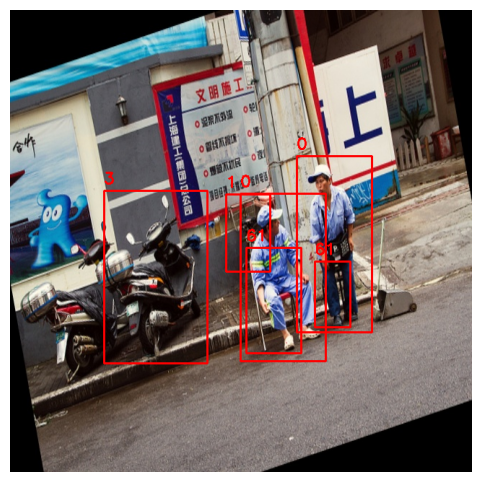

In [ ]:
# Función para visualizar una imagen con sus cajas
def mostrar_imagen_con_cajas(ruta_img, ruta_txt):
    imagen = cv2.imread(ruta_img)
    imagen = cv2.cvtColor(imagen, cv2.COLOR_BGR2RGB)  # Convertir BGR a RGB
    h, w, _ = imagen.shape

    # Leer las cajas
    cajas = []
    with open(ruta_txt, "r") as f:
        for linea in f:
            clase, x, y, ancho, alto = map(float, linea.strip().split())
            # Convertir coordenadas normalizadas a píxeles
            x1 = int((x - ancho/2) * w)
            y1 = int((y - alto/2) * h)
            x2 = int((x + ancho/2) * w)
            y2 = int((y + alto/2) * h)
            cajas.append((x1, y1, x2, y2, int(clase)))

    # Dibujar cajas
    for x1, y1, x2, y2, clase in cajas:
        cv2.rectangle(imagen, (x1, y1), (x2, y2), (255, 0, 0), 2)
        cv2.putText(imagen, str(clase), (x1, y1 - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 0, 0), 2)

    # Mostrar imagen
    plt.figure(figsize=(6,6))
    plt.imshow(imagen)
    plt.axis('off')
    plt.show()

# Elegir una imagen aumentada aleatoria
archivo = random.choice(os.listdir("data/val2017_aug"))
ruta_img_ejemplo = os.path.join("data/val2017_aug", archivo)
ruta_txt_ejemplo = os.path.join("data/labels_val2017_aug", archivo.replace(".jpg", ".txt"))

# Mostrar imagen con cajas
mostrar_imagen_con_cajas(ruta_img_ejemplo, ruta_txt_ejemplo)

### 5. Entrenamiento del Modelo: Configuración y entrenamiento del modelo YOLOv8. 

In [8]:
# Crear carpetas para dataset formateado
base = "data/dataset_yolo"
os.makedirs(f"{base}/images/train", exist_ok=True)
os.makedirs(f"{base}/images/val", exist_ok=True)
os.makedirs(f"{base}/labels/train", exist_ok=True)
os.makedirs(f"{base}/labels/val", exist_ok=True)

# Obtener lista de imágenes aumentadas
imagenes = os.listdir("data/val2017_aug")
imagenes = [img for img in imagenes if img.endswith(".jpg")]

# Separar 80% treino, 20% validação
train_imgs, val_imgs = train_test_split(imagenes, test_size=0.2, random_state=42)

# Copiar archivos
for img in train_imgs:
    shutil.copy(f"data/val2017_aug/{img}", f"{base}/images/train/{img}")
    shutil.copy(f"data/labels_val2017_aug/{img.replace('.jpg', '.txt')}", f"{base}/labels/train/{img.replace('.jpg', '.txt')}")

for img in val_imgs:
    shutil.copy(f"data/val2017_aug/{img}", f"{base}/images/val/{img}")
    shutil.copy(f"data/labels_val2017_aug/{img.replace('.jpg', '.txt')}", f"{base}/labels/val/{img.replace('.jpg', '.txt')}")


In [ ]:
# Cargar modelo YOLOv8 preentrenado
modelo = YOLO("yolov8n.pt")  # yolov8n = nano, rápido e leve

# Entrenar con nuestros datos
modelo.train(
    data="coco_val300.yaml",
    epochs=10,
    imgsz=640,
    batch=8
)